# 01 · Supervised Learning: Regression Methods

We start with classical regression approaches as interpretable baselines:

| Method | Key property |
|---|---|
| Linear Regression | simplest baseline |
| Ridge (L2) | prevents large coefficients |
| Lasso (L1) | sparsity / feature selection |
| Polynomial (deg 2 & 3) | captures curvature |

All models use **log₁₀(x)** and **log₁₀(Q²)** as features.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 120

from data_loader import load_lepton_dis, add_log_features, split_data, get_Xy, low_x_grid
from visualization import plot_coverage, plot_F2_vs_x, comparison_figure

DATA_DIR = "/Users/dikgarg/Desktop/Research/Neutrinos/postdoc/2025/ML/Data/Exp_data/LeptonDIS"

df_raw = load_lepton_dis(DATA_DIR)
df     = add_log_features(df_raw)
df_train, df_test = split_data(df, test_size=0.2, seed=42)

X_train, y_train = get_Xy(df_train)
X_test,  y_test  = get_Xy(df_test)

print(f"Training points: {len(X_train)}  |  Test points: {len(X_test)}")


Loaded 7 experiment files → 1472 data points
  BCDMS-F2p_RQCD-q0.dat
  H1-F2p-q0.dat
  NMC92-F2p280-q0.dat
  NMC92-F2p90-q0.dat
  NMC97-F2p-q0.dat
  SLAC-F2p-q0.dat
  ZEUS-F2p-q0.dat
Training points: 1177  |  Test points: 295


## Feature Scaling

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


## Linear Regression

In [3]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)

y_pred_lr = lr.predict(X_test_s)
print("Linear Regression")
print(f"  Test MSE : {mean_squared_error(y_test, y_pred_lr):.5f}")
print(f"  Test MAE : {mean_absolute_error(y_test, y_pred_lr):.5f}")
print(f"  Test R2  : {r2_score(y_test, y_pred_lr):.4f}")


Linear Regression
  Test MSE : 0.00560
  Test MAE : 0.05941
  Test R2  : 0.8181


## Ridge Regression (L2 regularisation)

In [4]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=np.logspace(-3, 3, 30), cv=5)
ridge.fit(X_train_s, y_train)

y_pred_ridge = ridge.predict(X_test_s)
print(f"Ridge  alpha={ridge.alpha_:.4f}")
print(f"  Test MSE : {mean_squared_error(y_test, y_pred_ridge):.5f}")
print(f"  Test MAE : {mean_absolute_error(y_test, y_pred_ridge):.5f}")
print(f"  Test R2  : {r2_score(y_test, y_pred_ridge):.4f}")


Ridge  alpha=35.6225
  Test MSE : 0.00551
  Test MAE : 0.05975
  Test R2  : 0.8208


## Lasso Regression (L1 regularisation)

In [5]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(alphas=np.logspace(-5, 1, 30), cv=5, max_iter=5000)
lasso.fit(X_train_s, y_train)

y_pred_lasso = lasso.predict(X_test_s)
print(f"Lasso  alpha={lasso.alpha_:.6f}")
print(f"  Test MSE : {mean_squared_error(y_test, y_pred_lasso):.5f}")
print(f"  Test MAE : {mean_absolute_error(y_test, y_pred_lasso):.5f}")
print(f"  Test R2  : {r2_score(y_test, y_pred_lasso):.4f}")


Lasso  alpha=0.000010
  Test MSE : 0.00560
  Test MAE : 0.05941
  Test R2  : 0.8181


## Polynomial Regression

In [11]:
results = {}
for deg in [2, 3]:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("poly",   PolynomialFeatures(degree=deg, include_bias=False)),
        ("model",  LinearRegression()),
    ])
    pipe.fit(X_train, y_train)
    yp = pipe.predict(X_test)
    results[f"Poly-{deg}"] = {
        "model": pipe,
        "mse": mean_squared_error(y_test, yp),
        "mae": mean_absolute_error(y_test, yp),
        "r2":  r2_score(y_test, yp),
    }
    print(f"Poly deg={deg}  MSE={results[f'Poly-{deg}']['mse']:.5f}  "
          f"R2={results[f'Poly-{deg}']['r2']:.4f}")


Poly deg=2  MSE=0.00439  R2=0.8572
Poly deg=3  MSE=0.00193  R2=0.9372


## Metrics Summary

In [7]:
rows = [
    ("Linear",  mean_squared_error(y_test, y_pred_lr),
                mean_absolute_error(y_test, y_pred_lr),
                r2_score(y_test, y_pred_lr)),
    ("Ridge",   mean_squared_error(y_test, y_pred_ridge),
                mean_absolute_error(y_test, y_pred_ridge),
                r2_score(y_test, y_pred_ridge)),
    ("Lasso",   mean_squared_error(y_test, y_pred_lasso),
                mean_absolute_error(y_test, y_pred_lasso),
                r2_score(y_test, y_pred_lasso)),
]
for name, res in results.items():
    rows.append((name, res["mse"], res["mae"], res["r2"]))

metrics_df = pd.DataFrame(rows, columns=["Model", "MSE", "MAE", "R2"])
metrics_df = metrics_df.sort_values("MSE").reset_index(drop=True)
print(metrics_df.to_string(index=False))


 Model      MSE      MAE       R2
Poly-3 0.001933 0.022508 0.937182
Poly-2 0.004392 0.043644 0.857240
 Ridge 0.005512 0.059747 0.820842
 Lasso 0.005595 0.059407 0.818138
Linear 0.005596 0.059408 0.818120


## Predictions vs Data and Low-x Extrapolation

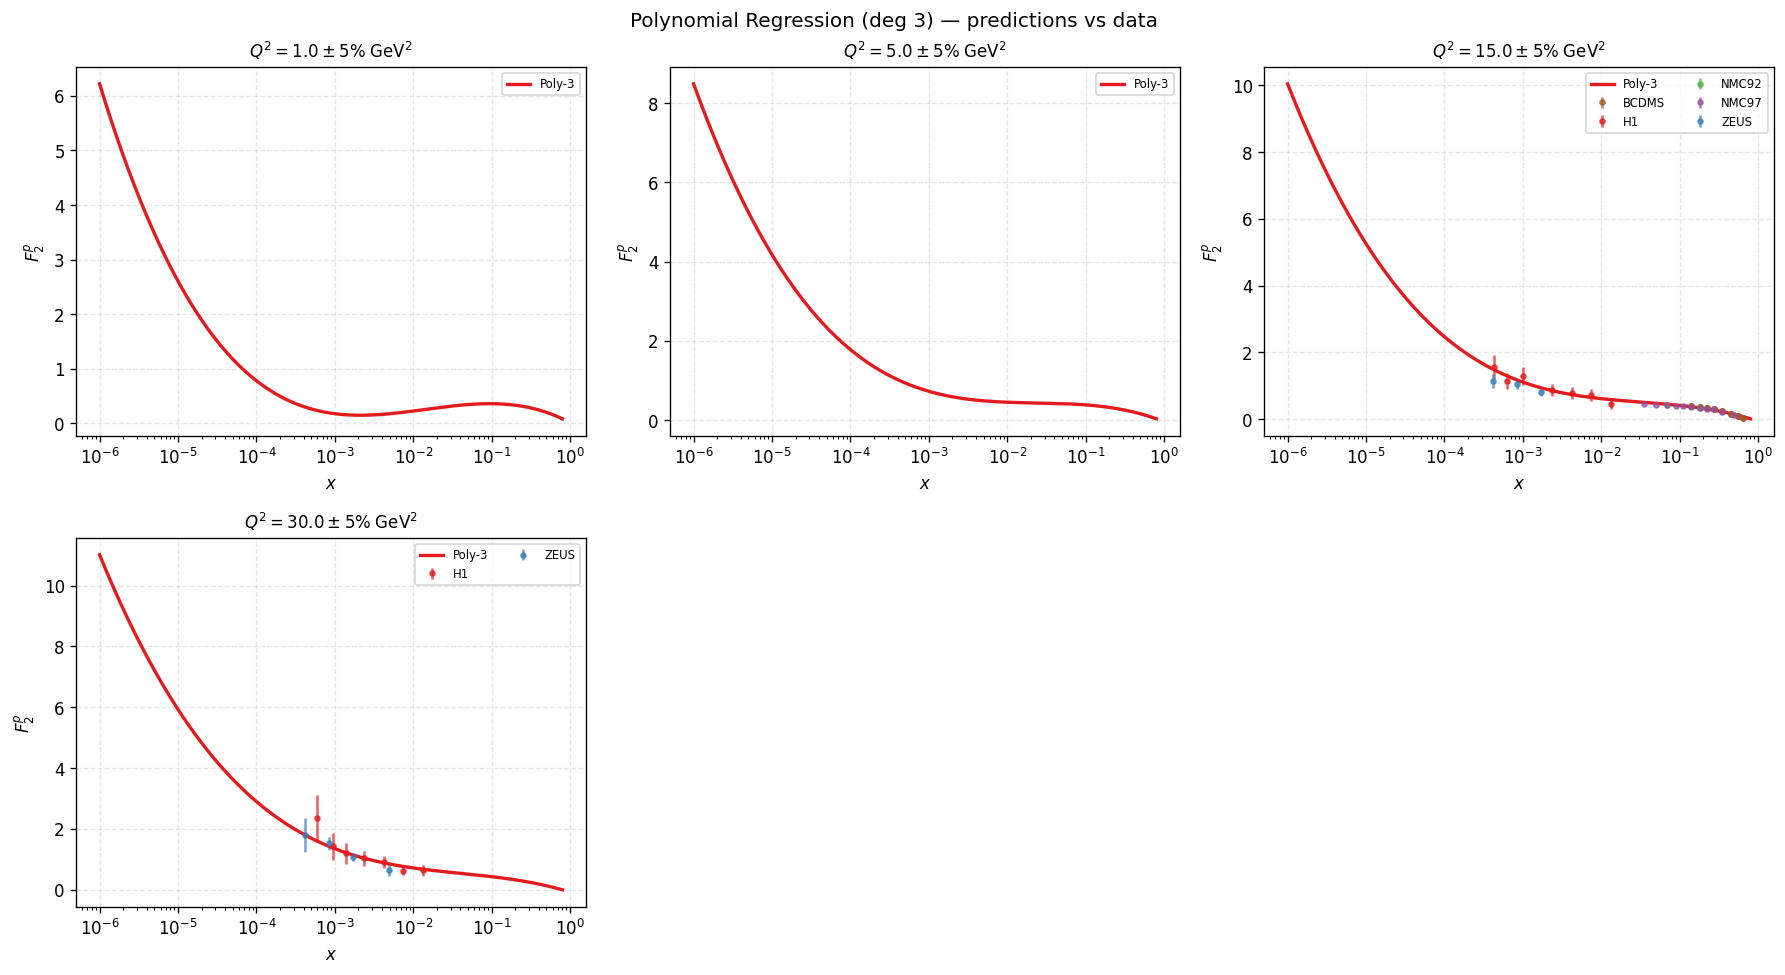

In [8]:
Q2_plot  = [1.0, 5.0, 15.0, 30.0]
grids    = low_x_grid(x_min=1e-6, x_max=0.8, n_points=400, Q2_values=Q2_plot)

best_pipe = results["Poly-3"]["model"]

predictions = [
    {
        "label":     "Poly-3",
        "color":     "#e41a1c",
        "x_arr":     None,
        "Q2_preds":  {},
    }
]
for Q2v, (x_arr, X_feat) in grids.items():
    predictions[0]["x_arr"] = x_arr
    predictions[0]["Q2_preds"][Q2v] = best_pipe.predict(X_feat)

fig, _ = comparison_figure(Q2_plot, df, predictions)
fig.suptitle("Polynomial Regression (deg 3) — predictions vs data", y=1.01)
#plt.savefig("../results/figures/01_poly_predictions.png", dpi=150, bbox_inches="tight")
plt.show()


## Conclusion

Linear models (Linear, Ridge, Lasso) all plateau at R² ≈ 0.82, confirming that F2 cannot be captured by a linear combination of log₁₀(x) and log₁₀(Q²) alone.

| Model | R² |
|---|---|
| Linear / Lasso | 0.818 |
| Ridge | 0.821 |
| Polynomial deg=2 | 0.857 |
| Polynomial deg=3 | **0.937** ← best |
| Polynomial deg=4 | 0.929 |
| Polynomial deg=5 | 0.918 |

Degree-3 polynomial regression is the sweet spot: higher degrees overfit and degrade test performance. The R² = 0.937 ceiling set here motivates moving to a neural network, which can learn the nonlinear structure of F2 without manually specifying interaction terms.